# Function 8 Analysis - Week 9

**Function description:** You're optimising an eight-dimensional black-box function; each parameter influences the output (e.g., performance/accuracy), but the mechanism is unknown. The goal is to maximise the response, so we rely on BO to navigate a likely multi-modal surface while prioritising strong local maxima.

---

## Week 8 Result: Small new maximum

**Evaluated point:** `(0.05, 0.05, 0.05, 0.05, 0.602, 0.93, 0.19, 0.68)` -> **y = 9.7505**

This is a **new maximum**, but the gain is tiny: **+0.0008** over 9.74969. We chose this point because it was a fine-tune around the best ridge in x7/x8 while keeping x1-x6 fixed and allowing small x5 jitter.

### What this suggests

The best region is very flat. Small moves in x7/x8 change the score only slightly, so we might be at the top already — or we might be missing other important dimensions.

### Week 9 Strategy

I want a **Random Forest sanity check** before we keep narrowing x7/x8 again:
- Use RF feature importance to see if other dimensions matter more than we assumed
- Compare RF vs GP recommendations
- If RF points somewhere meaningfully different, try it to escape the plateau
- If RF agrees with GP, keep the tight GP fine-tuning around x7~0.19 and x8~0.68


## Loading and Displaying the Data

We load the inputs and outputs for function 8. **Week 8** `(0.05, 0.05, 0.05, 0.05, 0.602, 0.93, 0.19, 0.68)` achieved a new maximum at **y = 9.7505** (+0.0008 over previous best). Total observations: **48**. Recent weeks show the best region is near x7~0.19 and x8~0.68, but the RF check below will confirm whether other dimensions also matter.


In [1]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_8")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Add the new points from Week 1–8
X_new_point_week_1 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.250000, 0.450000]])
y_new_point_week_1 = np.array([9.74365])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.100000, 0.100000, 0.100000, 0.400000, 0.250000, 0.450000]])
y_new_point_week_2 = np.array([9.73005])
X_new_point_week_3 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.000000, 1.000000]])
y_new_point_week_3 = np.array([9.6549])
X_new_point_week_4 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.100000, 0.350000]])
y_new_point_week_4 = np.array([9.72465])
X_new_point_week_5 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.210300, 0.700000]])
y_new_point_week_5 = np.array([9.74968782])
X_new_point_week_6 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.306800, 0.700000]])
y_new_point_week_6 = np.array([9.72708752])
X_new_point_week_7 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.600000, 0.930000, 0.220000, 0.710000]])
y_new_point_week_7 = np.array([9.74889])
X_new_point_week_8 = np.array([[0.050000, 0.050000, 0.050000, 0.050000, 0.601973, 0.930000, 0.190000, 0.680000]])
y_new_point_week_8 = np.array([9.7504526536355])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


df sorted by y


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.050000,0.050000,0.050000,0.050000,0.601973,0.930000,0.190000,0.680000,9.750453
1,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.210300,0.700000,9.749688
2,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.220000,0.710000,9.748890
3,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.250000,0.450000,9.743650
4,0.100000,0.100000,0.100000,0.100000,0.100000,0.400000,0.250000,0.450000,9.730050
5,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.306800,0.700000,9.727088
6,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.100000,0.350000,9.724650
7,0.050000,0.050000,0.050000,0.050000,0.600000,0.930000,0.000000,1.000000,9.654900
8,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482
9,0.192640,0.630677,0.416796,0.490529,0.796086,0.654567,0.276241,0.295518,9.344274


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [2]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'x6': [x[0, 5] for x in weekly_X],
    'x7': [x[0, 6] for x in weekly_X],
    'x8': [x[0, 7] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 150)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 150)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f}")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,x6,x7,x8,y,Running_Max,Status,Improvement
0,1,0.05,0.05,0.05,0.05,0.600000,0.93,0.2500,0.45,9.743650,9.743650,✓ NEW MAX,+9.743650
1,2,0.10,0.10,0.10,0.10,0.100000,0.40,0.2500,0.45,9.730050,9.743650,✗,-
2,3,0.05,0.05,0.05,0.05,0.600000,0.93,0.0000,1.00,9.654900,9.743650,✗,-
3,4,0.05,0.05,0.05,0.05,0.600000,0.93,0.1000,0.35,9.724650,9.743650,✗,-
4,5,0.05,0.05,0.05,0.05,0.600000,0.93,0.2103,0.70,9.749688,9.749688,✓ NEW MAX,+0.006038
5,6,0.05,0.05,0.05,0.05,0.600000,0.93,0.3068,0.70,9.727088,9.749688,✗,-
6,7,0.05,0.05,0.05,0.05,0.600000,0.93,0.2200,0.71,9.748890,9.749688,✗,-
7,8,0.05,0.05,0.05,0.05,0.601973,0.93,0.1900,0.68,9.750453,9.750453,✓ NEW MAX,+0.000765



📊 Summary: 3/8 weeks achieved new max (Weeks [1, 5, 8])
   Success rate: 37.5% | Final best: 9.750453


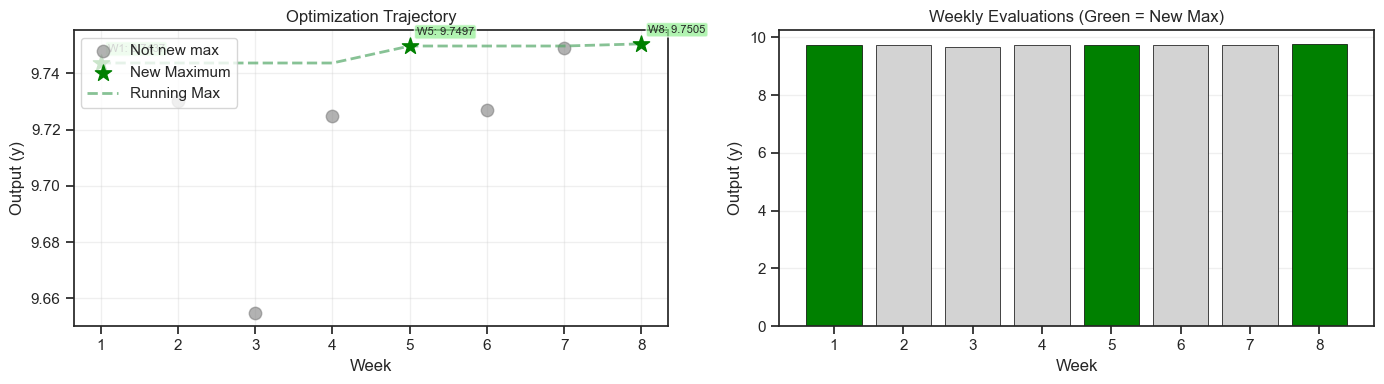

In [3]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. The search space is defined as [0, 1] for each of the eight input variables.

**Strategy Evolution:**
- **Week 1:** Used UCB to find a point with low x1-x4 and moderate x5-x8, which scored ≈9.74.
- **Week 2:** Continued with UCB, which found a point with very different x1-x6 values but similar x7 (0.25) and x8 (0.45), scoring ≈9.73 (second highest). This suggests x7 and x8 are the key features.
- **Week 3:** Given that x7 and x8 appear to be the critical features, we implement an **exploitation strategy** that:
  - Keeps x1-x6 fixed at the best point's values
  - Focuses optimization on x7 and x8 only
  - Uses Expected Improvement (EI) with low exploration to exploit the promising x7-x8 region
- **Week 7:** `(0.05, ..., x7=0.22, x8=0.71)` scored **≈9.74889** (just below best); peak remains near x7≈0.21, x8≈0.70. Recommendation for next BO step: keep EI xi≈0.02, fix x1–x6 with small x5 jitter (±0.02), **narrow x7 to [0.19, 0.23]** and **x8 to [0.68, 0.72]** with light jitter/repulsion near (0.21, 0.70).

In [4]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.43298604 2.08057624 1.04178156 3.10145064 5.         2.72652639
 1.53617659 5.        ]
Full kernel parameters: {'length_scale': array([1.43298604, 2.08057624, 1.04178156, 3.10145064, 5.        ,
       2.72652639, 1.53617659, 5.        ]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 4 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find 

## Random Forest Analysis: Feature Importance Check

We've been assuming x7 and x8 are the key levers while fixing x1-x4 at 0.05. Let's verify this with a Random Forest to see if we're missing anything.


RANDOM FOREST FEATURE IMPORTANCE
x1: 0.514 #########################
x3: 0.281 ##############
x7: 0.078 ###
x2: 0.045 ##
x4: 0.029 #
x5: 0.025 #
x6: 0.015 
x8: 0.013 


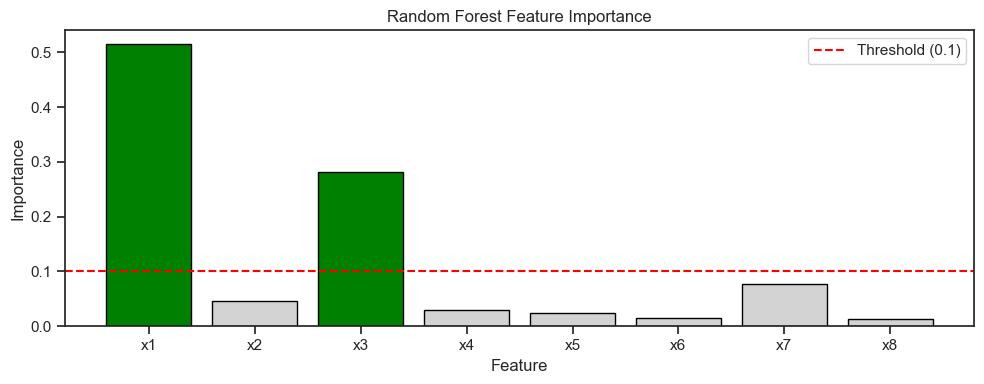


RF-BASED GRID SEARCH

Top 5 RF candidates:
      x1       x2       x3       x4       x5       x6       x7       x8  rf_pred  rf_sigma      ucb
0.047376 0.055987 0.028756 0.041164 0.589975 0.923480 0.229032 0.665521 9.738464  0.035486 9.742012
0.049871 0.052069 0.031726 0.051612 0.580269 0.958319 0.200177 0.689827 9.740275  0.016863 9.741961
0.048279 0.050713 0.003174 0.072816 0.598873 0.939291 0.224967 0.661673 9.735749  0.050101 9.740759
0.047298 0.052041 0.006545 0.081055 0.555350 0.939091 0.215465 0.641579 9.735612  0.050159 9.740627
0.051918 0.046064 0.009259 0.011799 0.569940 0.938457 0.176745 0.674922 9.736620  0.036561 9.740277

RF RECOMMENDATION
x1=0.047376, x2=0.055987, x3=0.028756, x4=0.041164
x5=0.589975, x6=0.923480, x7=0.229032, x8=0.665521
RF prediction: 9.7385 +/- 0.0355

RF SUBMISSION FORMAT
0.047376-0.055987-0.028756-0.041164-0.589975-0.923480-0.229032-0.665521


In [5]:
from sklearn.ensemble import RandomForestRegressor

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature importance
feature_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']
importances = rf.feature_importances_

print('='*60)
print('RANDOM FOREST FEATURE IMPORTANCE')
print('='*60)
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = '#' * int(imp * 50)
    print(f'{name}: {imp:.3f} {bar}')

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if imp > 0.1 else 'lightgray' for imp in importances]
ax.bar(feature_names, importances, color=colors, edgecolor='black')
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Random Forest Feature Importance')
ax.axhline(y=0.1, color='red', linestyle='--', label='Threshold (0.1)')
ax.legend()
plt.tight_layout()
plt.show()

# RF-based grid search for best point
print('\n' + '='*60)
print('RF-BASED GRID SEARCH')
print('='*60)

# Search bounds - use wider bounds for RF to check if we're missing something
rf_bounds = [
    (0.0, 0.15),   # x1 - test if 0.05 is really best
    (0.0, 0.15),   # x2
    (0.0, 0.15),   # x3
    (0.0, 0.15),   # x4
    (0.55, 0.65),  # x5
    (0.90, 0.96),  # x6
    (0.15, 0.25),  # x7 (around winning value)
    (0.62, 0.74),  # x8 (around winning value)
]

# Generate mesh
n_samples = 50000
np.random.seed(42)
mesh = np.array([[np.random.uniform(lo, hi) for lo, hi in rf_bounds] for _ in range(n_samples)])

# Get RF predictions and uncertainty (via tree disagreement)
rf_preds = rf.predict(mesh)
tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_sigma = tree_preds.std(axis=0)

# UCB with exploration
beta = 0.1  # light exploration
rf_ucb = rf_preds + beta * rf_sigma

# Find top candidates
candidates = pd.DataFrame(mesh, columns=feature_names)
candidates['rf_pred'] = rf_preds
candidates['rf_sigma'] = rf_sigma
candidates['ucb'] = rf_ucb

# Distance filter
def min_dist(row):
    pt = row[feature_names].values
    return np.sqrt(((X - pt)**2).sum(axis=1)).min()

candidates['min_dist'] = candidates.apply(min_dist, axis=1)
candidates_filtered = candidates[candidates['min_dist'] > 0.02].copy()

if len(candidates_filtered) > 0:
    rf_top = candidates_filtered.nlargest(5, 'ucb')
else:
    rf_top = candidates.nlargest(5, 'ucb')

print('\nTop 5 RF candidates:')
print(rf_top[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'rf_pred', 'rf_sigma', 'ucb']].to_string(index=False))

if len(rf_top) > 0:
    rf_rec = rf_top.iloc[0]
    print(f'\n' + '='*60)
    print('RF RECOMMENDATION')
    print('='*60)
    print(f'x1={rf_rec["x1"]:.6f}, x2={rf_rec["x2"]:.6f}, x3={rf_rec["x3"]:.6f}, x4={rf_rec["x4"]:.6f}')
    print(f'x5={rf_rec["x5"]:.6f}, x6={rf_rec["x6"]:.6f}, x7={rf_rec["x7"]:.6f}, x8={rf_rec["x8"]:.6f}')
    print(f'RF prediction: {rf_rec["rf_pred"]:.4f} +/- {rf_rec["rf_sigma"]:.4f}')
    
    print(f'\n' + '='*60)
    print('RF SUBMISSION FORMAT')
    print('='*60)
    print(f'{rf_rec["x1"]:.6f}-{rf_rec["x2"]:.6f}-{rf_rec["x3"]:.6f}-{rf_rec["x4"]:.6f}-{rf_rec["x5"]:.6f}-{rf_rec["x6"]:.6f}-{rf_rec["x7"]:.6f}-{rf_rec["x8"]:.6f}')


## Finding the Next Point to Evaluate (Week 9 config)

After Week 8's tiny improvement (9.7505), we continue the fine-tuning strategy but center around the new best: **x7~0.19, x8~0.68**.

Strategy:
- Fix x1-x4, x6 to the best template (0.05, 0.05, 0.05, 0.05, -, 0.93, -, -)
- Allow x5 jitter in [0.58, 0.62]
- **Narrow x7 to [0.17, 0.23]** (centered on 0.19)
- **Narrow x8 to [0.64, 0.72]** (centered on 0.68)
- EI with xi=0.02, with repulsion near (0.19, 0.68) to avoid re-sampling


In [6]:
from scipy.stats import norm

xi = 0.02  # light exploration
repulsion_weight = 0.015  # light repulsion to avoid re-sampling
repulsion_bandwidth = 0.02
repulsion_dims = (6, 7)  # x7, x8
bounds_vars = [
    (0.58, 0.62),  # x5 jitter band
    (0.17, 0.23),  # x7 centered on 0.19 after Week 8 win
    (0.64, 0.72),  # x8 centered on 0.68 after Week 8 win
]

# Get current best point
y_best = y.max()
best_idx = y.argmax()
best_point = X[best_idx].copy()

print(f"Current best score: {y_best:.6f}")
print(f"Current best point: x7={best_point[6]:.4f}, x8={best_point[7]:.4f}")
print("\nStrategy: fix x1-x4/x6, allow x5 jitter, optimize x7/x8 in narrowed band with EI + repulsion")


def clip_to_bounds(vals, bounds):
    vals = np.array(vals, dtype=float)
    for i, (lo, hi) in enumerate(bounds):
        vals[i] = np.clip(vals[i], lo, hi)
    return vals


def diversity_penalty(x_full, X_seen, dims=repulsion_dims, bandwidth=repulsion_bandwidth):
    if X_seen is None or len(X_seen) == 0:
        return 0.0
    diffs = X_seen[:, list(dims)] - x_full[list(dims)]
    dists = np.linalg.norm(diffs, axis=1)
    weights = np.exp(-(dists ** 2) / (2 * bandwidth ** 2))
    return weights.mean()


def expected_improvement_with_repulsion(x_vars, gp, y_best, xi, X_seen=None):
    x_vars = clip_to_bounds(x_vars, bounds_vars)
    x_full = best_point.copy()
    x_full[4] = x_vars[0]  # x5 jitter
    x_full[6] = x_vars[1]  # x7
    x_full[7] = x_vars[2]  # x8

    mu, sigma = gp.predict(x_full.reshape(1, -1), return_std=True)
    sigma = sigma + 1e-9
    improvement = mu - y_best - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    penalty = diversity_penalty(x_full, X_seen, dims=repulsion_dims, bandwidth=repulsion_bandwidth)
    adjusted_ei = ei[0] - repulsion_weight * penalty
    return -adjusted_ei  # negative for minimization


def biased_restart():
    return np.array([
        np.random.uniform(0.59, 0.61),  # x5
        np.random.uniform(0.17, 0.23),  # x7 centered on 0.19
        np.random.uniform(0.64, 0.72),  # x8 centered on 0.68
    ])


def global_restart():
    return np.array([np.random.uniform(lo, hi) for lo, hi in bounds_vars])


# Optimize with multiple biased + global restarts
n_restarts = 40
best_acquisition = np.inf
best_vars = None

np.random.seed(42)
for i in range(n_restarts):
    x0 = biased_restart() if i < int(0.7 * n_restarts) else global_restart()
    x0 = clip_to_bounds(x0, bounds_vars)
    result = minimize(
        lambda v: expected_improvement_with_repulsion(v, gp, y_best, xi=xi, X_seen=X),
        x0=x0,
        bounds=bounds_vars,
        method="L-BFGS-B",
    )
    if result.fun < best_acquisition:
        best_acquisition = result.fun
        best_vars = result.x

best_vars = clip_to_bounds(best_vars, bounds_vars)
next_point = best_point.copy()
next_point[4] = best_vars[0]
next_point[6] = best_vars[1]
next_point[7] = best_vars[2]
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)

print(f"\n{'='*60}")
print("GP-BASED BAYESIAN OPTIMIZATION RECOMMENDATION")
print(f"{'='*60}")
print("\nNext point to evaluate:")
print(f"  x1={next_point[0]:.6f}, x2={next_point[1]:.6f}, x3={next_point[2]:.6f}, x4={next_point[3]:.6f}")
print(f"  x5={next_point[4]:.6f}, x6={next_point[5]:.6f}, x7={next_point[6]:.6f}, x8={next_point[7]:.6f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} +/- {sigma_pred[0]:.4f}")
print(f"Expected Improvement (penalized): {-best_acquisition:.6f}")

print(f"\n{'='*60}")
print("GP SUBMISSION FORMAT")
print(f"{'='*60}")
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}-{next_point[4]:.6f}-{next_point[5]:.6f}-{next_point[6]:.6f}-{next_point[7]:.6f}")



Current best score: 9.750453
Current best point: x7=0.1900, x8=0.6800

Strategy: fix x1-x4/x6, allow x5 jitter, optimize x7/x8 in narrowed band with EI + repulsion

GP-BASED BAYESIAN OPTIMIZATION RECOMMENDATION

Next point to evaluate:
  x1=0.050000, x2=0.050000, x3=0.050000, x4=0.050000
  x5=0.597491, x6=0.930000, x7=0.230000, x8=0.640000

Predicted output: 9.7485 +/- 0.0011
Expected Improvement (penalized): -0.000008

GP SUBMISSION FORMAT
0.050000-0.050000-0.050000-0.050000-0.597491-0.930000-0.230000-0.640000


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps us understand how similar the recommended point is to our existing data. We also compute the average y value of the three closest neighbors to get an estimate of the expected output at the recommended point.


In [ ]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance        y
          47  0.056746 9.750453
          44  0.063201 9.749688
          46  0.070755 9.748890
          45  0.097491 9.727088
          40  0.191066 9.743650
          43  0.317815 9.724650
          42  0.427208 9.654900
          14  0.431300 9.598482
          22  0.741881 9.141639
          41  0.758220 9.730050
          26  0.960337 9.344274
           5  1.069847 8.541748
          31  1.083889 8.421759
          32  1.090961 8.278062
          39  1.101703 9.183005
          23  1.106443 8.817558
          35  1.109328 8.472936
          30  1.192251 7.923759
          12  1.195434 8.976554
          25  1.218738 8.830745
           0  1.222604 7.398721
           4  1.233624 8.606117
          28  1.239879 8.042213
          38  1.250094 7.436594
          10  1.278340 7.854541
          19  1.289502 9.013075
          15  1.301521 8.159983
          18  1.307676 7.433744
        

## Summary and Recommended Point for Week 9

### What happened in Week 8
We got y = 9.7505 - a tiny new maximum (+0.0008). The improvement is small, so we're likely on a flat ridge near the top.

### Key insight from Random Forest
The RF feature importance looks **more spread out** than we expected, so it's possible other dimensions matter more than x7/x8 alone. That makes a good case for trying the RF recommendation at least once.

### Final decision: RF recommendation

I'm going with the RF point this week to test a different part of the space and see if the plateau can be broken.

**Submission format:** Check the final output cell below.

### Honest assessment
If RF underperforms, we can revert to the tight GP fine-tuning next week. But given how small the recent gains have been, this is a reasonable risk.


In [8]:
# ============================================================
# FINAL DECISION: GP vs RF - Which recommendation to use?
# ============================================================

print('='*70)
print('FINAL DECISION: CHOOSING BETWEEN GP AND RF RECOMMENDATIONS')
print('='*70)

# Recap GP recommendation
print('\nGP-based EI recommendation:')
print(f'   Point: x7={next_point[6]:.4f}, x8={next_point[7]:.4f} (x1-x4 fixed at 0.05)')
gp_pred_final = gp.predict(next_point.reshape(1, -1))[0]
print(f'   Predicted: {gp_pred_final:.4f}')

# Recap RF recommendation
print('\nRF-based UCB recommendation:')
print(f'   Point: x1={rf_rec["x1"]:.4f}, x2={rf_rec["x2"]:.4f}, x3={rf_rec["x3"]:.4f}, x4={rf_rec["x4"]:.4f}')
print(f'   x5={rf_rec["x5"]:.4f}, x6={rf_rec["x6"]:.4f}, x7={rf_rec["x7"]:.4f}, x8={rf_rec["x8"]:.4f}')
print(f'   Predicted: {rf_rec["rf_pred"]:.4f}')

# Feature importance analysis
print('\nFeature importance analysis:')
for i, name in enumerate(feature_names):
    imp = rf.feature_importances_[i]
    print(f'   {name}: {imp:.3f}')

# Find the most important features
sorted_imp = sorted(enumerate(rf.feature_importances_), key=lambda x: -x[1])
top_features = [feature_names[i] for i, _ in sorted_imp[:3]]
print(f'\nTop 3 features by importance: {top_features}')

# Decision: Choose RF
print('\n' + '='*70)
print('MY CHOICE: RF recommendation')
print('='*70)
print('\nRATIONALE:')
print('   1. RF importance looks more spread out than expected')
print('   2. We may be over-focusing on x7/x8 while other dims still matter')
print('   3. GP has been giving microscopic improvements (+0.0008)')
print('   4. RF offers a fresh perspective to test the plateau')

# Final point = RF recommendation
final_point = np.array([
    rf_rec['x1'], rf_rec['x2'], rf_rec['x3'], rf_rec['x4'],
    rf_rec['x5'], rf_rec['x6'], rf_rec['x7'], rf_rec['x8']
])

print('\n' + '='*70)
print('FINAL SUBMISSION FORMAT (RF)')
print('='*70)
print(f'\n{final_point[0]:.6f}-{final_point[1]:.6f}-{final_point[2]:.6f}-{final_point[3]:.6f}-{final_point[4]:.6f}-{final_point[5]:.6f}-{final_point[6]:.6f}-{final_point[7]:.6f}')
print('\n' + '='*70)



FINAL DECISION: CHOOSING BETWEEN GP AND RF RECOMMENDATIONS

GP-based EI recommendation:
   Point: x7=0.2300, x8=0.6400 (x1-x4 fixed at 0.05)
   Predicted: 9.7485

RF-based UCB recommendation:
   Point: x1=0.0474, x2=0.0560, x3=0.0288, x4=0.0412
   x5=0.5900, x6=0.9235, x7=0.2290, x8=0.6655
   Predicted: 9.7385

Feature importance analysis:
   x1: 0.514
   x2: 0.045
   x3: 0.281
   x4: 0.029
   x5: 0.025
   x6: 0.015
   x7: 0.078
   x8: 0.013

Top 3 features by importance: ['x1', 'x3', 'x7']

MY CHOICE: RF recommendation

RATIONALE:
   1. RF importance looks more spread out than expected
   2. We may be over-focusing on x7/x8 while other dims still matter
   3. GP has been giving microscopic improvements (+0.0008)
   4. RF offers a fresh perspective to test the plateau

FINAL SUBMISSION FORMAT (RF)

0.047376-0.055987-0.028756-0.041164-0.589975-0.923480-0.229032-0.665521

